In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
#loading the data set
data = pd.read_csv("/Users/furkhanansari/Desktop/Data Science/DataSets/train.csv")

In [6]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# survived = 1 ; not survived = 0

In [8]:
#data types
print(data.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [9]:
# prportion passengers survived

data.groupby('Survived')['PassengerId'].count()

Survived
0    549
1    342
Name: PassengerId, dtype: int64

In [10]:
#visual exploration

<Axes: xlabel='Survived', ylabel='Age'>

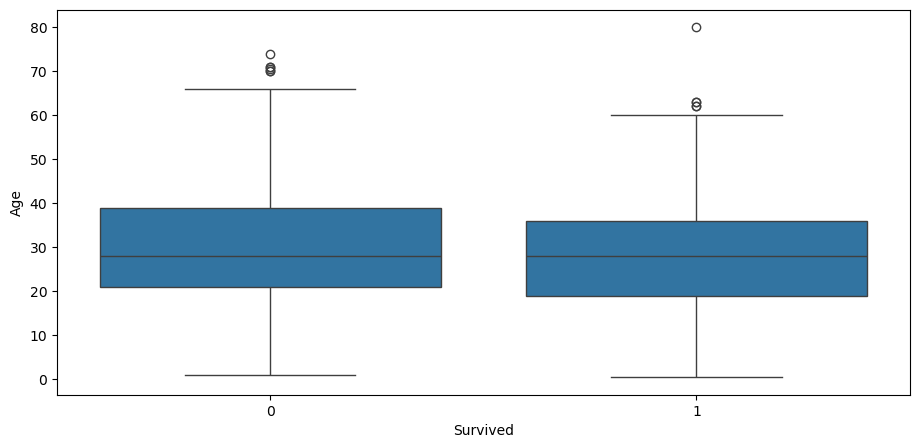

In [11]:
f , ax = plt.subplots(figsize=(11,5))
sns.boxplot(x='Survived' , y = 'Age' , data = data)

<Axes: xlabel='Sex', ylabel='Survived'>

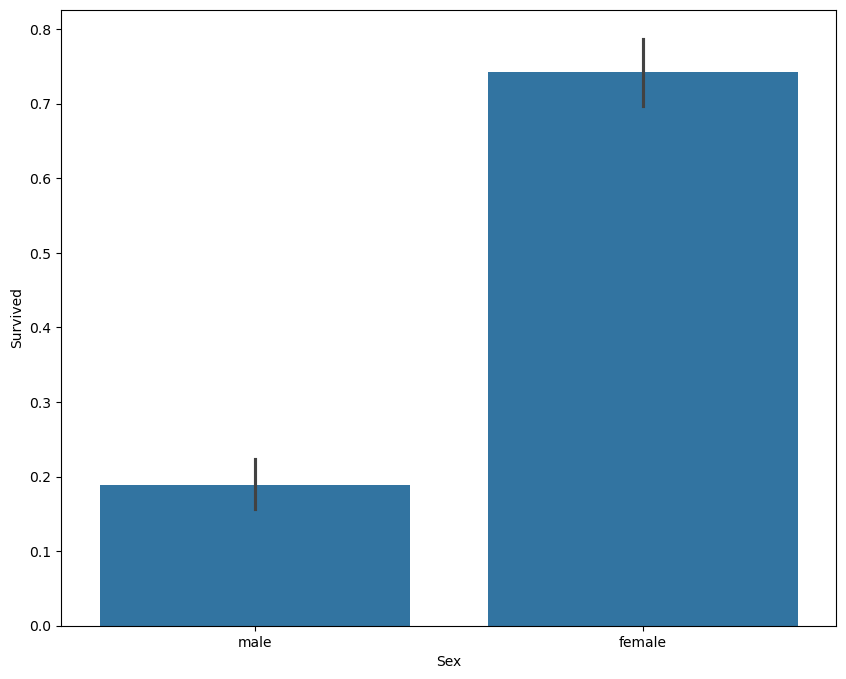

In [12]:
f , ax = plt.subplots(figsize=(10,8))
sns.barplot(y='Survived' , x = 'Sex' , data = data)

<Axes: xlabel='Sex', ylabel='Age'>

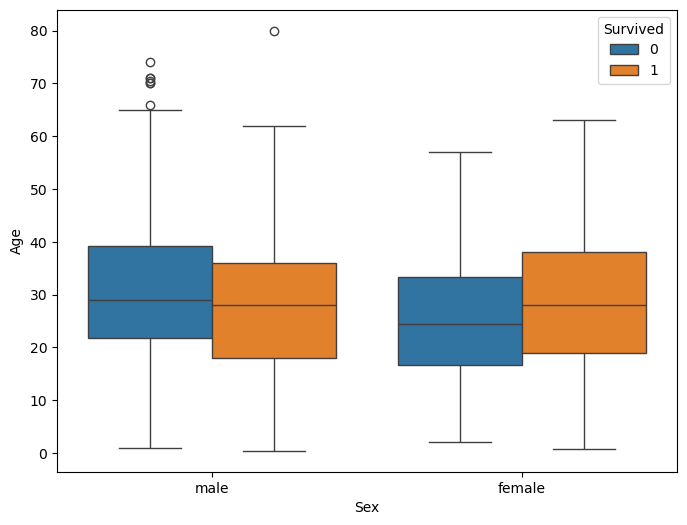

In [13]:
f , ax = plt.subplots(figsize=(8,6))
sns.boxplot(x='Sex' , y = 'Age' ,hue = 'Survived', data = data)

<Axes: xlabel='Pclass', ylabel='Survived'>

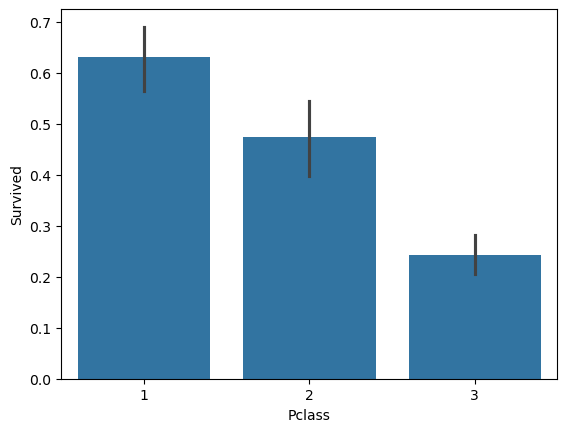

In [14]:
sns.barplot(x='Pclass',y = 'Survived' , data =data)

<Axes: xlabel='Pclass', ylabel='Survived'>

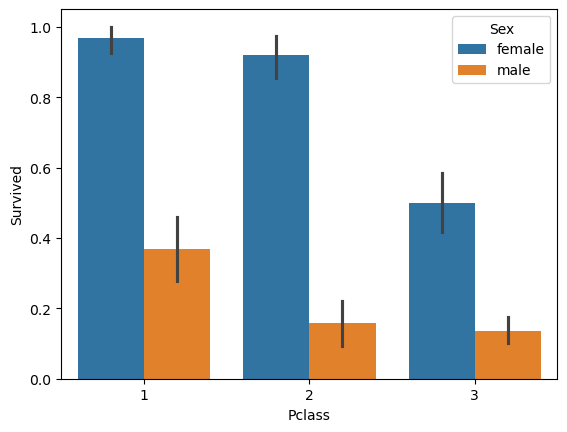

In [15]:
sns.barplot(x='Pclass',y = 'Survived' ,hue = 'Sex', data =data)

<Axes: xlabel='SibSp', ylabel='Survived'>

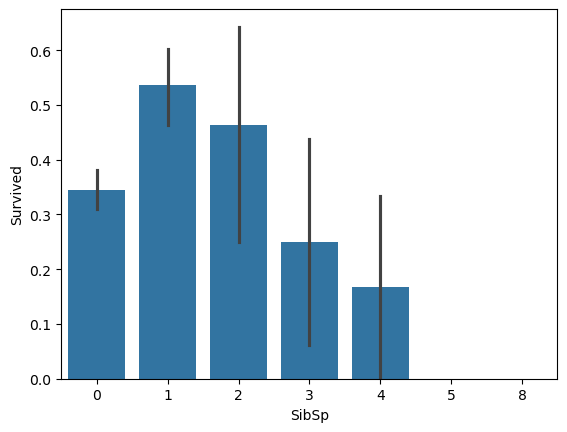

In [16]:
sns.barplot(x='SibSp' , y = 'Survived' ,data=data)

<Axes: xlabel='Parch', ylabel='Survived'>

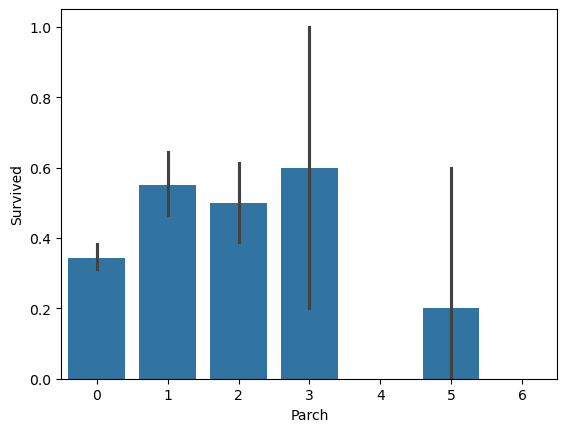

In [17]:
sns.barplot(x='Parch' , y = 'Survived' ,data=data)

/var/folders/7b/rp_b1btd04154v527_55nf140000gn/T/ipykernel_69318/1105573374.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(survived)


Text(0.5, 1.0, 'survived')

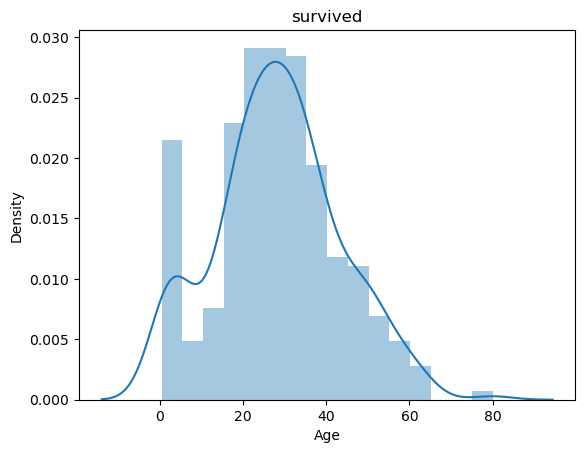

In [18]:
survived = data.loc[data['Survived']==1,'Age'].dropna()
sns.distplot(survived)
plt.title('survived')

/var/folders/7b/rp_b1btd04154v527_55nf140000gn/T/ipykernel_69318/2646458334.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(not_survived)


<Axes: xlabel='Age', ylabel='Density'>

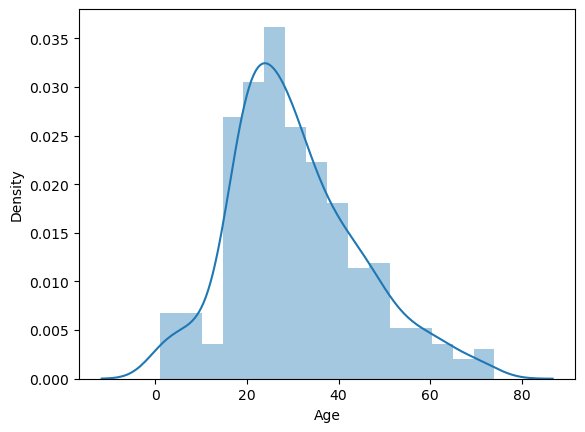

In [19]:
not_survived = data.loc[data['Survived'] == 0 , 'Age'].dropna()
sns.distplot(not_survived)

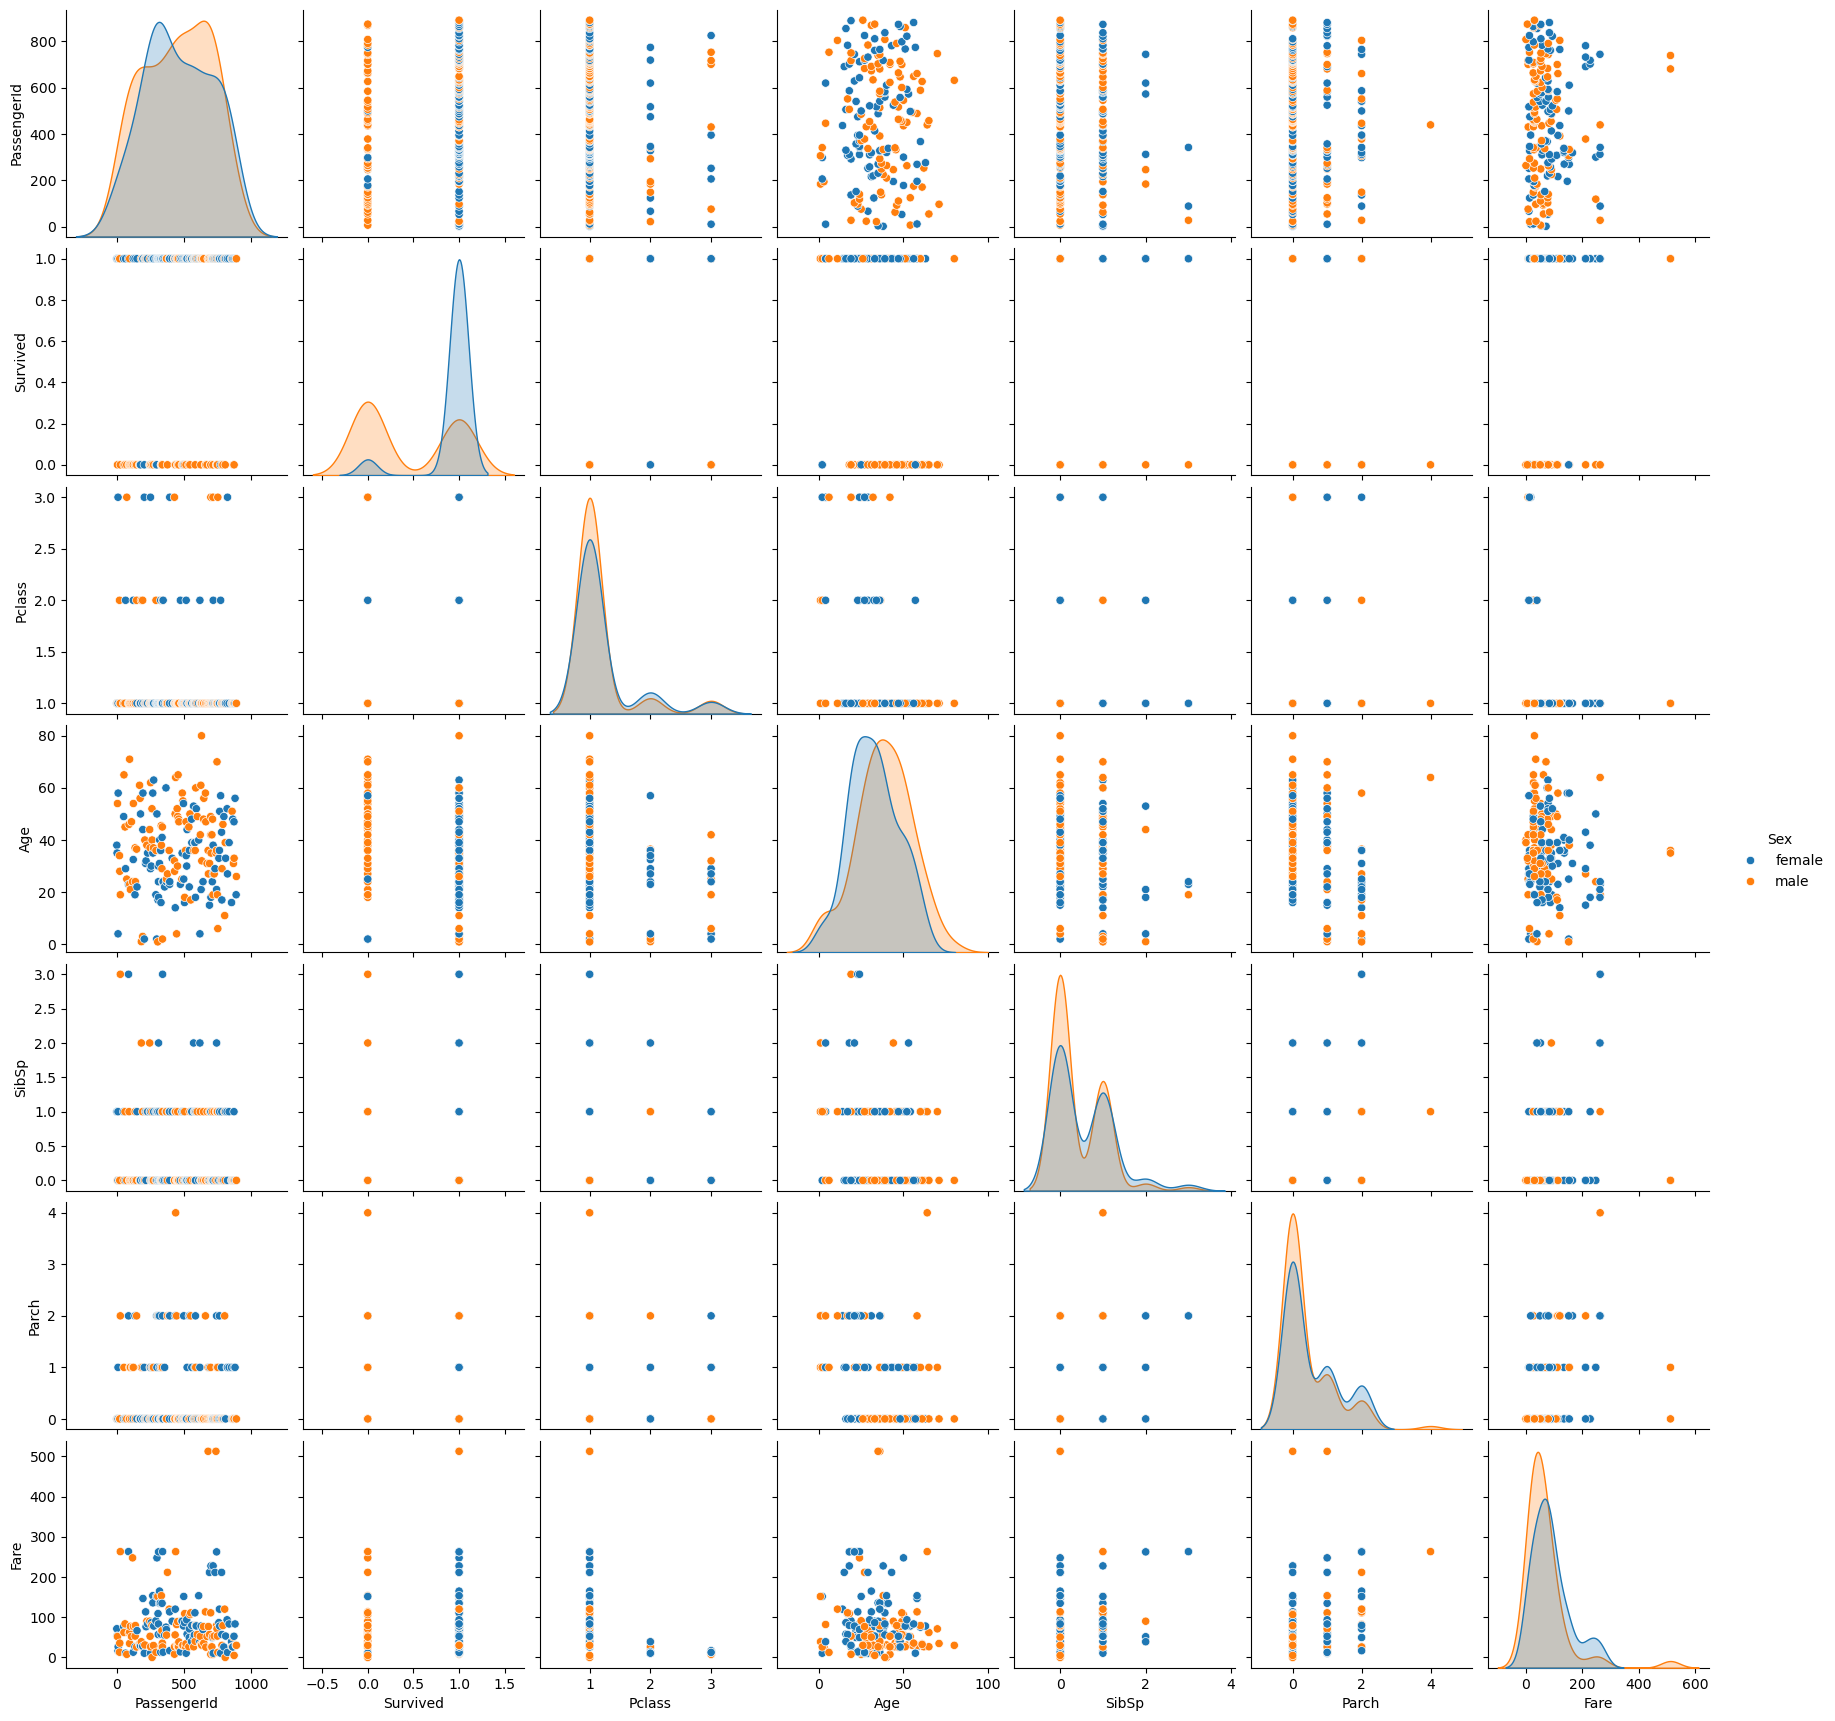

In [20]:
sns.pairplot(data.dropna(),hue = 'Sex')

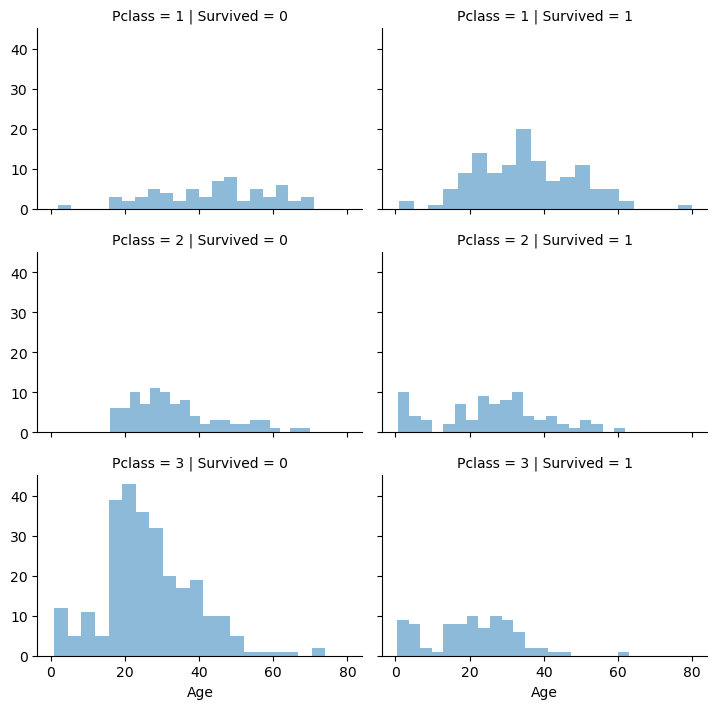

In [21]:
# pclass vs Survive   and Age
grid = sns.FacetGrid(data,col='Survived',row='Pclass',height=2.4,aspect=1.5)      #size --> height new version
grid.map(plt.hist,'Age',alpha = .5 , bins=20)
grid.add_legend()

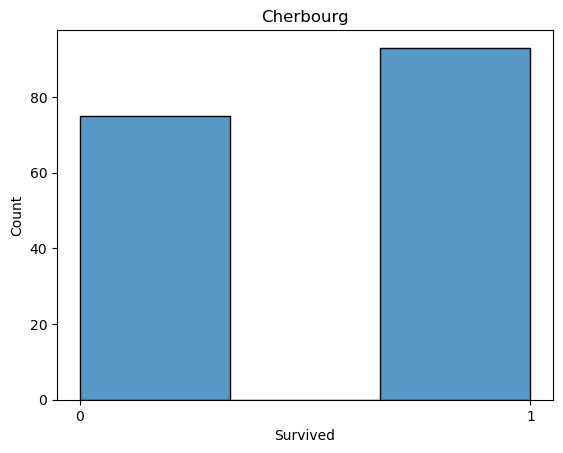

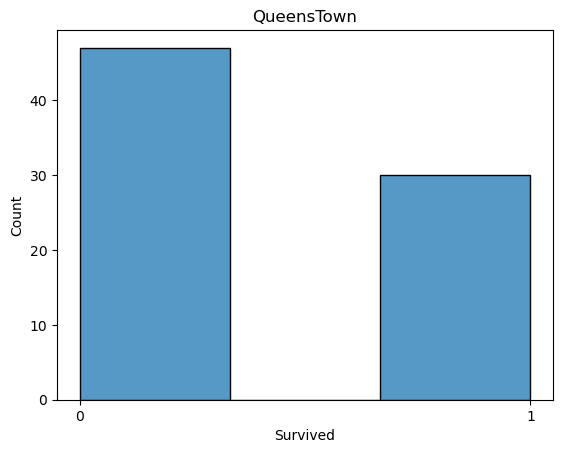

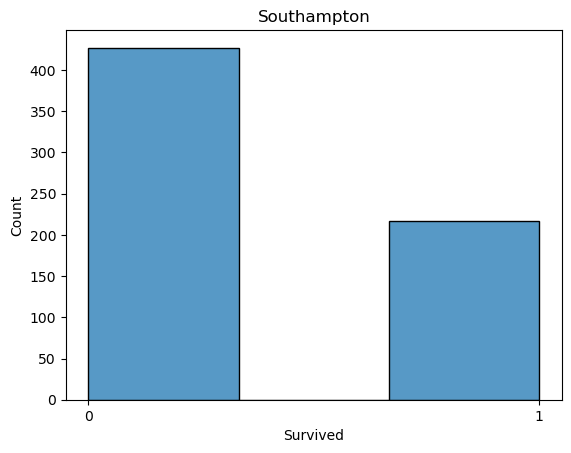

In [22]:
sns.histplot(x=data[data['Embarked']=='C']['Survived'],bins=3,kde=False)
plt.title("Cherbourg")
plt.xticks([0,1])
plt.show()
sns.histplot(x=data[data['Embarked']=='Q']['Survived'],bins=3,kde=False)
plt.title("QueensTown")
plt.xticks([0,1])
plt.show()
sns.histplot(x=data[data['Embarked']=='S']['Survived'],bins=3,kde=False)
plt.title("Southampton")
plt.xticks([0,1])
plt.show()

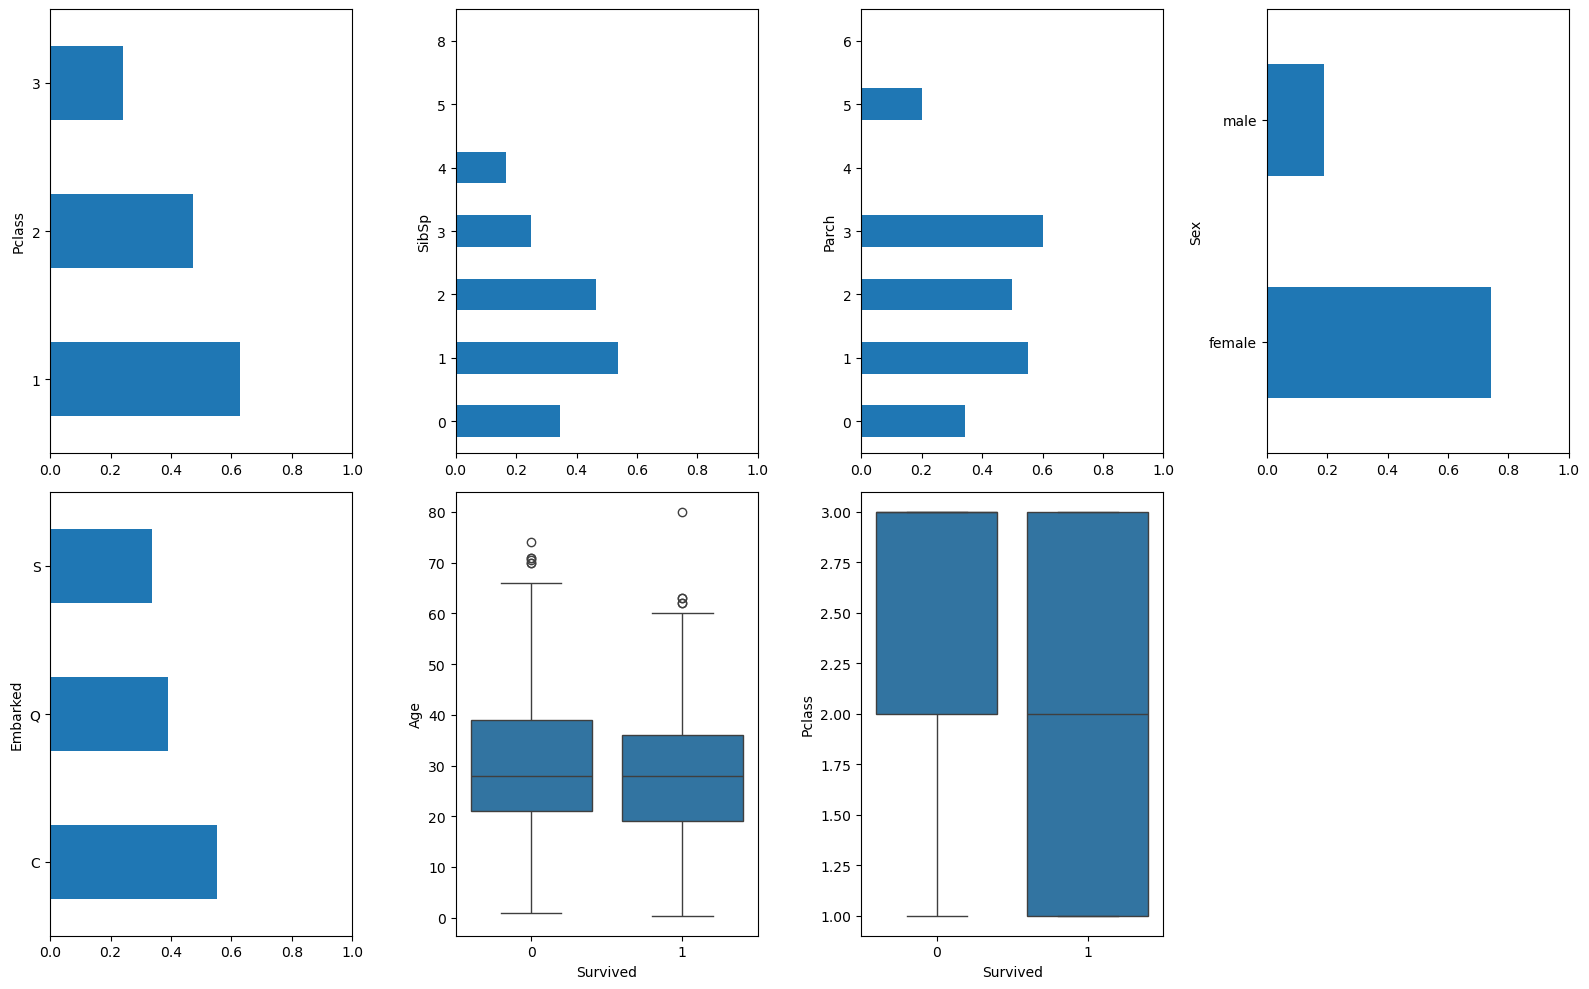

In [24]:
figbi , axesbi = plt.subplots(2,4,figsize=(16,10))
data.groupby('Pclass')['Survived'].mean().plot(kind='barh',ax=axesbi[0,0],xlim=[0,1])
data.groupby('SibSp')['Survived'].mean().plot(kind='barh',ax=axesbi[0,1],xlim=[0,1])
data.groupby('Parch')['Survived'].mean().plot(kind='barh',ax=axesbi[0,2],xlim=[0,1])
data.groupby('Sex')['Survived'].mean().plot(kind='barh',ax=axesbi[0,3],xlim=[0,1])
data.groupby('Embarked')['Survived'].mean().plot(kind='barh',ax=axesbi[1,0],xlim=[0,1])
sns.boxplot(x='Survived',y='Age',data=data,ax=axesbi[1,1])
sns.boxplot(x='Survived',y='Pclass',data=data,ax=axesbi[1,2])
axesbi[1, 3].set_visible(False)
plt.tight_layout()
plt.show()